In [1]:
import warnings

import ase
import matplotlib.pyplot as plt
import numpy as np

import abtem

abtem.config.set({"diagnostics.progress_bar": False})

# the frozen-phonon configurations are deliberately kept unaveraged below
warnings.filterwarnings("ignore", message="ensemble_mean=False");

(tutorials:phonon_loss)=
# Phonon-loss spectroscopy

In a standard [frozen-phonon](walkthrough:frozen_phonons) simulation, a set of configurations sampling the thermal displacements is averaged incoherently. The diffuse part of that average — the difference between the incoherent and the coherent sum — is the thermal diffuse scattering (TDS), and it lumps together every phonon the electron could have excited, at every energy.

Since version `1.1.0`, *ab*TEM can resolve that signal in energy. Instead of a single set of configurations, an `EnergyResolvedAtomsEnsemble` holds one *group* of configurations per energy bin, so the TDS decomposition can be applied bin by bin. The result is a set of energy-resolved diffraction patterns, from which `momentum_resolved_spectrum` builds the momentum-resolved spectrum $S(q, E)$ measured in vibrational EELS.

The energy resolution comes entirely from how the configurations are made: *ab*TEM does not calculate the phonons. The displacement patterns and the energy assigned to each group come from an external lattice-dynamics or molecular-dynamics calculation — or, as below, from a model.

## A model phonon

We use aluminium in the $\left<100\right>$ zone axis and populate one longitudinal acoustic mode at a time. A mode with scattering vector $q$ along $x$ displaces the atoms as

$u_x(x) = A \cos(2 \pi q x + \phi) \quad ,$

where the phase $\phi$ is what we sample: the frozen-phonon configurations of an energy bin are snapshots of the same standing mode taken at random phases. Only wavelengths commensurate with the supercell are allowed, so $q = m / L$ for integer $m$, where $L$ is the length of the supercell.

We assign an energy to each mode with the dispersion of a monatomic chain,

$E(q) = E_{\mathrm{max}} \left| \sin(\pi q d) \right| \quad ,$

with $d = a / 2$ the spacing of the $\{200\}$ planes and $E_{\mathrm{max}} = 37 \ \mathrm{meV}$ at the zone boundary. Every mode is given the same amplitude, so the *intensities* below carry no physical meaning — only the positions of the peaks do. A realistic calculation would take both the displacement patterns and their amplitudes from lattice dynamics.

In [2]:
a = 4.05
num_cells = 16

crystal = ase.build.bulk("Al", cubic=True, a=a) * (num_cells, 4, 10)

L = num_cells * a  # length of the supercell along x
d = a / 2  # spacing of the {200} planes
maximum_energy = 0.037  # eV, at the zone boundary

orders = np.arange(2, 18, 2)
q_values = orders / L  # 1/Å
energies = maximum_energy * np.sin(np.pi * q_values * d)  # eV

for q, energy in zip(q_values, energies):
    print(f"q = {q:.4f} 1/Å,  E = {energy * 1e3:5.1f} meV")

q = 0.0309 1/Å,  E =   7.2 meV
q = 0.0617 1/Å,  E =  14.2 meV
q = 0.0926 1/Å,  E =  20.6 meV
q = 0.1235 1/Å,  E =  26.2 meV
q = 0.1543 1/Å,  E =  30.8 meV
q = 0.1852 1/Å,  E =  34.2 meV
q = 0.2160 1/Å,  E =  36.3 meV
q = 0.2469 1/Å,  E =  37.0 meV


The configurations of one energy bin are snapshots of the same mode at sixteen random phases. We add a zero-energy bin holding copies of the undisplaced crystal — a bin with no phonon, which is required by the thermal weighting further below and which serves as a useful check: its diffuse intensity must vanish exactly.

In [3]:
amplitude = 0.1  # Å
num_configs = 16

rng = np.random.default_rng(13)


def displace(atoms, q, phase):
    displaced = atoms.copy()
    x = displaced.positions[:, 0]
    displaced.positions[:, 0] += amplitude * np.cos(2 * np.pi * q * x + phase)
    return displaced


snapshots = [[crystal.copy() for _ in range(num_configs)]]

for q in q_values:
    phases = rng.uniform(0, 2 * np.pi, num_configs)
    snapshots.append([displace(crystal, q, phase) for phase in phases])

all_energies = np.concatenate([[0.0], energies])

Each configuration is the perfect crystal with a single sinusoidal displacement wave frozen into it.

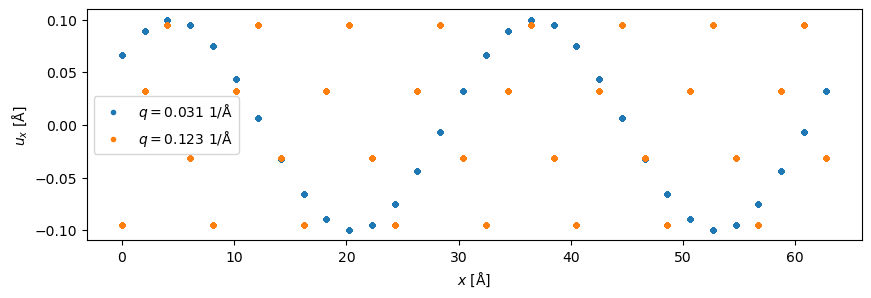

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))

for i in (0, 3):
    displacement = snapshots[i + 1][0].positions[:, 0] - crystal.positions[:, 0]
    ax.plot(
        crystal.positions[:, 0],
        displacement,
        ".",
        label=f"$q = {q_values[i]:.3f}$ 1/Å",
    )

ax.set_xlabel("$x$ [Å]")
ax.set_ylabel("$u_x$ [Å]")
ax.legend();

## The energy-resolved ensemble

`EnergyResolvedAtomsEnsemble` wraps the snapshots together with the energy of each group. We set `ensemble_mean=False`, since the TDS decomposition needs the individual configurations rather than their average.

In [5]:
ensemble = abtem.EnergyResolvedAtomsEnsemble(
    energy_resolved_snapshots=snapshots,
    energies=all_energies,
    ensemble_mean=False,
)

ensemble.ensemble_shape

(9, 16)

The ensemble is used as the atomic model of a `Potential`, which then carries two ensemble axes: an `EnergyLossAxis` and a `FrozenPhononsAxis`.

```{tip}
With more than one slice, build the potential with `projection="finite"` rather than the default `projection="infinite"`. The infinite projection assigns each atom to exactly one slice with a hard cutoff, so an atom sitting close to a slice boundary can move its whole contribution to the neighbouring slice between two otherwise nearly identical configurations, which shows up as a spurious contribution to the diffuse signal. Our mode displaces the atoms in-plane only, but real displacement patterns generally have a $z$-component.
```

In [6]:
potential = abtem.Potential(
    ensemble, sampling=0.08, slice_thickness=a / 2, projection="finite"
)

exit_waves = abtem.PlaneWave(energy=100e3).multislice(potential).compute()

exit_waves.axes_metadata

type               label             coordinates
-----------------  ----------------  -------------------
EnergyLossAxis     energy loss [eV]  0.00 0.01 ... 0.04
FrozenPhononsAxis  Frozen phonons    -
RealSpaceAxis      x [Å]             0.00 0.08 ... 64.72
RealSpaceAxis      y [Å]             0.00 0.08 ... 16.12

## Coherent, incoherent and diffuse intensity

`phonon_loss_diffraction_patterns` collapses the frozen-phonon axis into the usual decomposition, one energy bin at a time:

$I_{\mathrm{coherent}} = \left| \frac{1}{N}\sum_j \mathcal{F} \psi_j \right|^2 \quad , \qquad I_{\mathrm{incoherent}} = \frac{1}{N} \sum_j \left| \mathcal{F} \psi_j \right|^2 \quad , \qquad I_{\mathrm{tds}} = I_{\mathrm{incoherent}} - I_{\mathrm{coherent}} \quad .$

Passing `component="all"` returns all three stacked along a new leading axis. Below we show them for the mode at the zone boundary: the coherent part holds the Bragg reflections of the average lattice, while the diffuse part holds the phonon satellites at $\vec{G} \pm \vec{q}$.

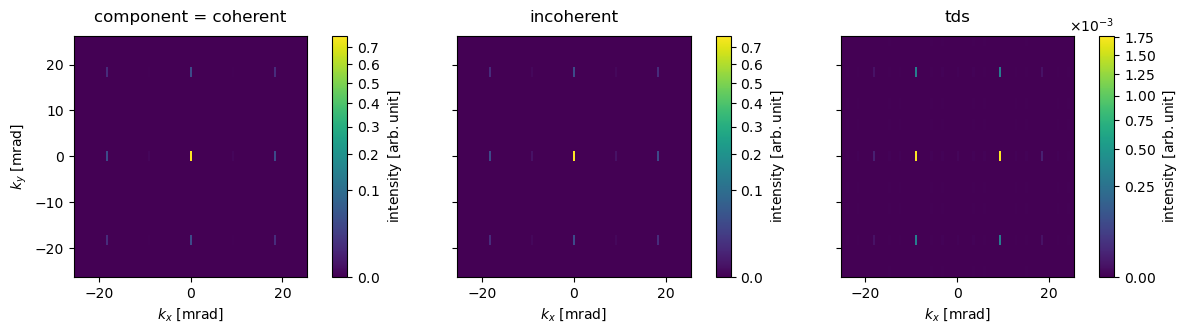

In [7]:
dp_components = abtem.phonon_loss_diffraction_patterns(
    exit_waves, component="all", max_angle=25
)

visualization = dp_components[:, -1].show(
    explode=True, units="mrad", figsize=(13, 4), cbar=True, power=0.5
)

## The momentum-resolved spectrum

Keeping only the diffuse component, we sweep a detector outwards along $q$ for every energy bin. `SpectralSlitDetector` integrates a rectangular strip of full width `width` perpendicular to the sweep direction; `momentum_resolved_spectrum` applies it to the energy-resolved patterns and returns a `MomentumResolvedSpectrum`, that is $S(q, E)$.

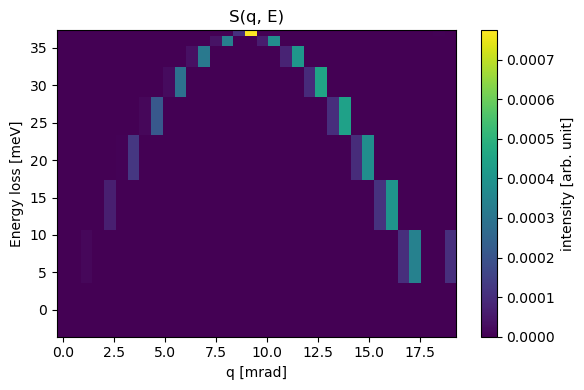

In [8]:
dp_tds = abtem.phonon_loss_diffraction_patterns(exit_waves)  # component="tds"

detector = abtem.SpectralSlitDetector(width=1.0, q_min=0.0, q_max=19.0, angle=0.0)

spectrum = abtem.momentum_resolved_spectrum(dp_tds, detector)

spectrum.show(cbar=True);

The dispersion we put in is recovered — twice. Each mode scatters intensity to $\vec{G} \pm \vec{q}$ around *every* Bragg reflection, so the branch rising from the direct beam is mirrored by a branch descending towards the $\{200\}$ reflection at $18.3 \ \mathrm{mrad}$. The two meet at the zone boundary, halfway between the reflections, where the satellites of the two coincide and the intensity is correspondingly higher.

The zero-energy bin is empty, as it must be: with identical configurations the incoherent and coherent sums agree exactly and the diffuse intensity is zero.

```{warning}
$I_{\mathrm{tds}}$ is the variance of the diffracted amplitude over the configurations of a bin, so at least two of them are required — a single configuration gives exactly zero, and *ab*TEM raises a `ValueError` rather than returning a silently empty result. Sixteen configurations, as used here, is few; a converged spectrum needs considerably more.
```

Use `crop` to zoom in on part of the spectrum. Besides restricting the axes, it rescales the colour scale to the cropped region, which is what makes the weak low-$q$ end visible here.

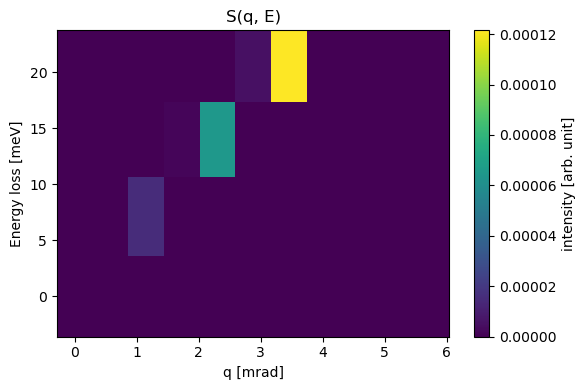

In [9]:
spectrum.crop(q_range=(0, 6), e_range=(0, 0.025)).show(cbar=True);

## Loss and gain sides

A frozen-phonon calculation is classical: it produces the same diffuse intensity whether the electron loses energy to a phonon or gains energy from one, and a single multislice run per energy *magnitude* is all that is needed. Splitting that intensity into the physical loss ($+E$, a phonon is created) and gain ($-E$, a phonon is annihilated) sides is a quantum, temperature-dependent effect, given by detailed balance with the Bose-Einstein occupation $n = 1 / (e^{E / k_B T} - 1)$:

$I_{\mathrm{loss}}(+E) = I_{\mathrm{tds}}(E) \frac{n + 1}{2n + 1} \quad , \qquad I_{\mathrm{gain}}(-E) = I_{\mathrm{tds}}(E) \frac{n}{2n + 1} \quad .$

Passing a `temperature` applies this split, mirroring the energy axis about zero. The total weight at each energy magnitude is conserved, and the zero bin passes through unweighted.

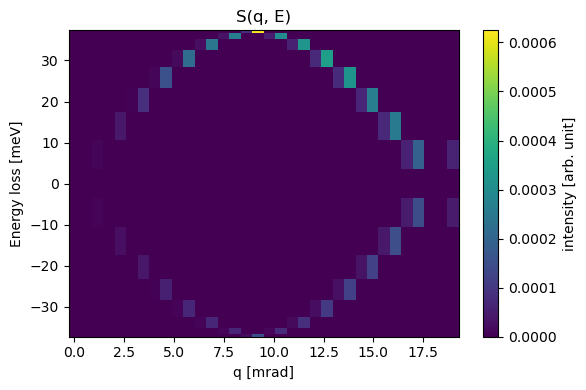

In [10]:
dp_weighted = abtem.phonon_loss_diffraction_patterns(
    exit_waves, component="tds", temperature=300.0
)

spectrum_weighted = abtem.momentum_resolved_spectrum(dp_weighted, detector)

spectrum_weighted.show(cbar=True);

At room temperature $k_B T \approx 26 \ \mathrm{meV}$ is comparable to the phonon energies here, so the gain side is only somewhat weaker than the loss side; it is suppressed much more strongly at low temperature or for higher-energy modes.

## Slit and disk detectors

`SpectralAnnularDetector` sweeps a circular acceptance disk of radius `outer` along $q$ instead of integrating a strip. The two detectors share the `q_min` and `q_max` convention, and cover the same acceptance perpendicular to the sweep when `width = 2 * outer`.

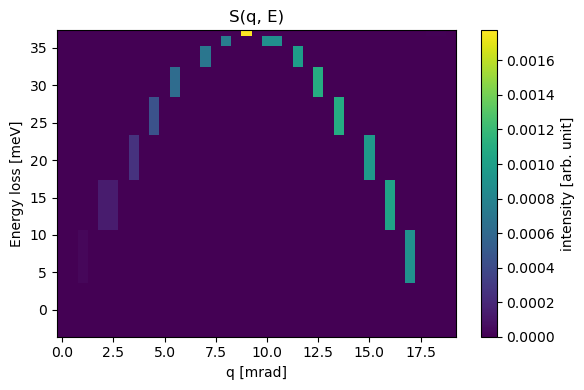

In [11]:
annular_detector = abtem.SpectralAnnularDetector(
    outer=0.5, q_min=0.0, q_max=19.0, angle=0.0
)

spectrum_annular = abtem.momentum_resolved_spectrum(dp_tds, annular_detector)

spectrum_annular.show(cbar=True);

```{note}
Both detectors also take an `angle`, which sets the direction of the sweep, and an `offset` (slit) that moves its origin away from the centre of the diffraction pattern — for example to follow a branch outwards from a chosen Bragg reflection rather than from the direct beam. The slit can alternatively be given as `corners=(kx_min, kx_max, ky_min, ky_max)`.
```

```{seealso}
The [core-loss tutorial](tutorials:core_loss) covers the complementary case of inelastic scattering from *electronic* excitations, where the energy loss is set by the atomic transition rather than by a phonon.
```